# 📊 SimSiam v2 — 資料分析 Notebook

> Jupyter 版本的 `analyze_data.py`，每個步驟即時繪圖輸出，並增加拓撲複雜度分析。

## 0. 環境設定與套件載入

In [1]:
import sys, os, random, json, warnings
from pathlib import Path

# === 確保 src 可正確 import ===
# Jupyter kernel 可能預先載入了其他 'src' 模組，需要清除衝突
_NB_DIR = Path(os.getcwd()).resolve()
_V2_DIR = None
for _c in [_NB_DIR, _NB_DIR / 'v2', _NB_DIR.parent, _NB_DIR.parent / 'v2']:
    if (_c / 'src' / 'data').is_dir():
        _V2_DIR = _c
        break
assert _V2_DIR is not None, f'找不到 src/data 目錄 (CWD={_NB_DIR})'

# 清除可能衝突的 src 模組快取
for key in list(sys.modules.keys()):
    if key == 'src' or key.startswith('src.'):
        del sys.modules[key]

if str(_V2_DIR) not in sys.path:
    sys.path.insert(0, str(_V2_DIR))

_PROJ_DIR = _V2_DIR.parent

print(f'Python:  {sys.executable}')
print(f'CWD:     {_NB_DIR}')
print(f'src 路徑: {_V2_DIR}')
print(f'project 路徑: {_PROJ_DIR}')

import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from collections import Counter
import concurrent.futures

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# 載入中文字體
_FONT = _V2_DIR / 'NotoSansTC-VariableFont_wght.ttf'
if _FONT.exists():
    from matplotlib import font_manager
    font_manager.fontManager.addfont(str(_FONT))
    prop = font_manager.FontProperties(fname=str(_FONT))
    matplotlib.rcParams['font.family'] = prop.get_name()
    matplotlib.rcParams['axes.unicode_minus'] = False

from src.data.preprocessing import binarize, discover_components
from src.data.topology import count_holes, analyze_topology, topology_preserving_pruning, sort_crops_by_topology
from src.data.logo_removal import remove_logo

# 提升 Pillow 的像素安全上限 (若您的影像極大，需開啟此設定)
Image.MAX_IMAGE_PIXELS = None 

# 用於記錄第一筆錯誤，避免終端機被錯誤訊息洗版
_error_logged = False

print('✅ 環境載入完成')

Python:  /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/.venv/bin/python
CWD:     /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/v2
src 路徑: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/v2
project 路徑: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training
✅ 環境載入完成


## 1. 設定參數與影像探索

In [2]:
# === 設定區 (可自由修改) ===
DATA_DIR = _PROJ_DIR.joinpath('data/converted_images')
SAMPLE_N = 500       # 像素強度取樣數
CC_SAMPLE_N = 500    # CC 分析取樣數
TOPO_SAMPLE_N = 500   # 拓撲分析取樣數
SEED = 64
TOP_N = 5
MAX_BBOX_RATIO = 0.7
PADDING = 2
USE_TOPOLOGY_PRUNING = True
MIN_SIMPLE_AREA = 100
PRUNING_ITERS = 20
PRUNING_KSIZE = 5
LOGO_MASK_REGION = [0.75, 0.8, 1, 1]
LOGO_TEMPLATE = 'data/Gifu_logo.png'

rng = random.Random(SEED)
np_rng = np.random.default_rng(SEED)

_IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
all_images = sorted([p for p in DATA_DIR.rglob('*') if p.suffix.lower() in _IMG_EXTS])
print(f'📁 資料目錄: {DATA_DIR}')
print(f'🖼️  影像總數: {len(all_images):,}')

📁 資料目錄: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/data/converted_images
🖼️  影像總數: 94,524


## 2. 影像尺寸分佈

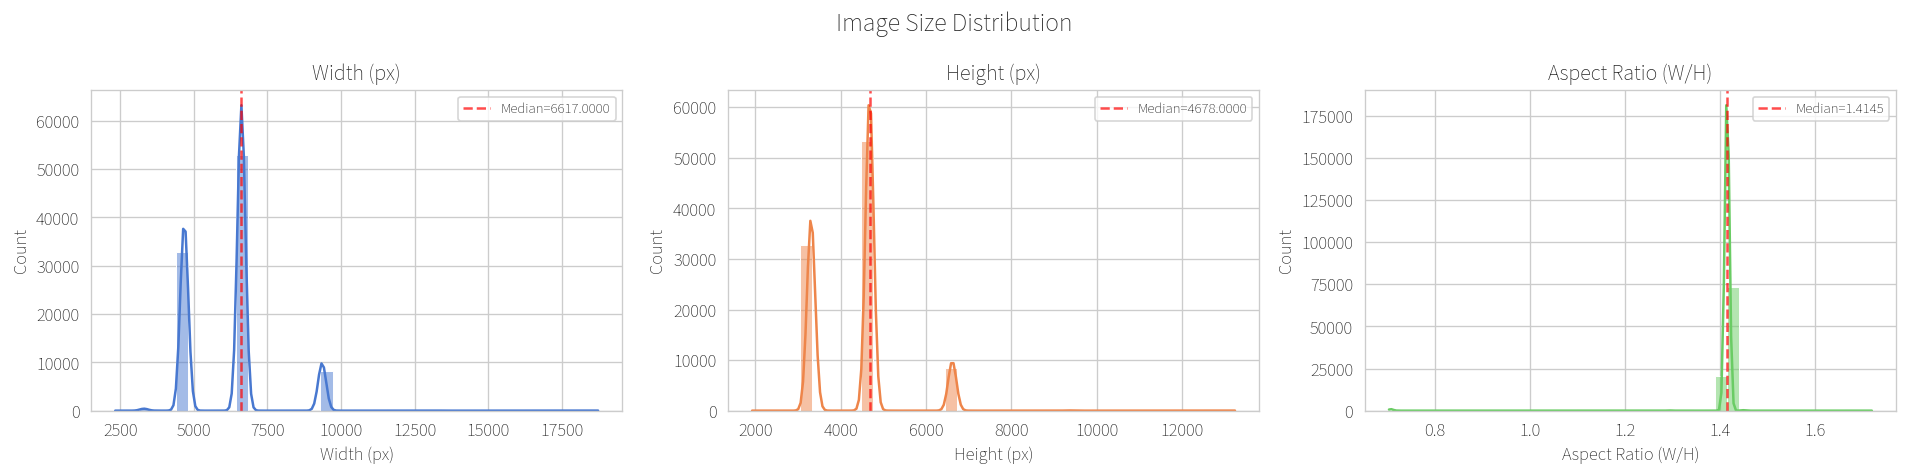

,width,height,aspect_ratio
count,94524.00,94524.00,94524.00
mean,6173.97,4377.46,1.41
std,1355.22,955.82,0.05
min,2334.00,1923.00,0.70
25%,4678.00,3306.00,1.41
50%,6617.00,4678.00,1.41
75%,6617.00,4678.00,1.42
max,18725.00,13245.00,1.72


In [3]:
# 定義單一檔案的尺寸提取邏輯
def get_image_size(path):
    global _error_logged
    str_path = str(path)
    
    # 策略一 (Fast Path)：嘗試低開銷的 Pillow 標頭讀取
    try:
        with Image.open(str_path) as img:
            return img.size  # 回傳 (width, height)
            
    except Exception as e:
        # 印出第一筆錯誤供工程診斷
        if not _error_logged:
            print(f"\n[診斷資訊] PIL 讀取失敗，已自動觸發 cv2 降級機制。")
            print(f"首筆失敗檔案: {str_path}")
            print(f"錯誤類型: {type(e).__name__} - {str(e)}")
            _error_logged = True
            
        # 策略二 (Fallback)：降級使用 OpenCV 進行高容錯解碼
        try:
            # 使用原本您驗證過可行的 cv2 讀取方式
            img_cv = cv2.imread(str_path, cv2.IMREAD_GRAYSCALE)
            if img_cv is not None:
                h, w = img_cv.shape
                return w, h
            else:
                return None, None
        except Exception:
            return None, None

widths, heights, ratios = [], [], []

# 使用執行緒池平行處理 I/O 任務
# max_workers 可根據您的硬體規格調整，預設為 CPU 核心數 + 4
with concurrent.futures.ThreadPoolExecutor() as executor:
    # 使用 executor.map 確保輸出順序，並將任務派發給執行緒池
    results = executor.map(get_image_size, all_images)
    
    for w, h in results:
        if w is not None and h is not None:
            widths.append(w)
            heights.append(h)
            ratios.append(w / h if h > 0 else 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette('muted')
for ax, data, label, color in zip(
    axes,
    [widths, heights, ratios],
    ['Width (px)', 'Height (px)', 'Aspect Ratio (W/H)'],
    palette[:3]
):
    sns.histplot(data, bins=40, ax=ax, color=color, kde=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

    median_val = float(np.median(data))
    ax.axvline(median_val, color='red', ls='--', alpha=0.7, label=f'Median={np.median(data):.4f}')
    ax.legend(fontsize=8)

fig.suptitle('Image Size Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

size_df = pd.DataFrame({'width': widths, 'height': heights, 'aspect_ratio': ratios})
display(size_df.describe().round(2))

## 3. 像素強度分析

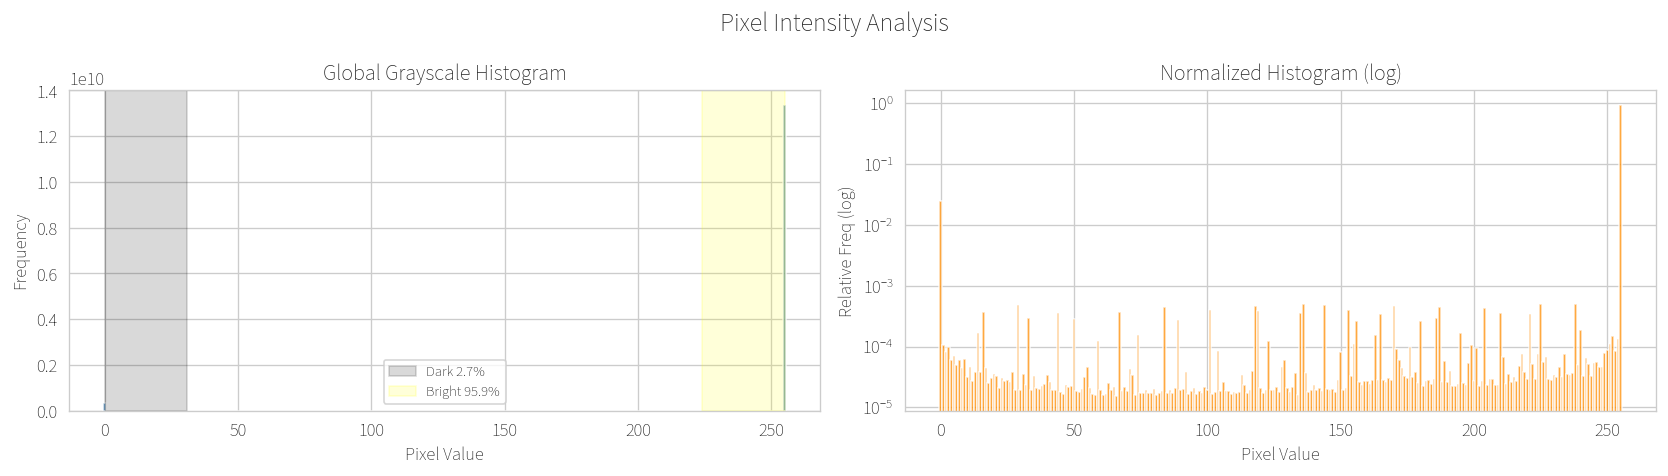

Mean pixel: 246.0 | Std: 42.7
Dark(0-31): 2.7% | Mid(32-223): 1.4% | Bright(224-255): 95.9%


In [4]:
sample = all_images if len(all_images) <= SAMPLE_N else rng.sample(all_images, SAMPLE_N)
global_hist = np.zeros(256, dtype=np.int64)
means, stds = [], []
for p in sample:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    global_hist += hist.astype(np.int64)
    means.append(float(np.mean(img))); stds.append(float(np.std(img)))

total_px = int(global_hist.sum())
pct_dark = float(global_hist[:32].sum() / max(total_px, 1))
pct_bright = float(global_hist[224:].sum() / max(total_px, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.bar(range(256), global_hist, width=1, color='steelblue', alpha=0.75)
ax.set_xlabel('Pixel Value'); ax.set_ylabel('Frequency'); ax.set_title('Global Grayscale Histogram')
ax.axvspan(0, 31, alpha=0.15, color='black', label=f'Dark {pct_dark:.1%}')
ax.axvspan(224, 255, alpha=0.15, color='yellow', label=f'Bright {pct_bright:.1%}')
ax.legend(fontsize=8)
ax = axes[1]
hist_norm = global_hist / max(global_hist.sum(), 1)
ax.bar(range(256), hist_norm, width=1, color='darkorange', alpha=0.75)
ax.set_yscale('log'); ax.set_xlabel('Pixel Value'); ax.set_ylabel('Relative Freq (log)')
ax.set_title('Normalized Histogram (log)')
fig.suptitle('Pixel Intensity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Mean pixel: {np.mean(means):.1f} | Std: {np.mean(stds):.1f}')
print(f'Dark(0-31): {pct_dark:.1%} | Mid(32-223): {1-pct_dark-pct_bright:.1%} | Bright(224-255): {pct_bright:.1%}')

## 4. 連通元件 (CC) 統計

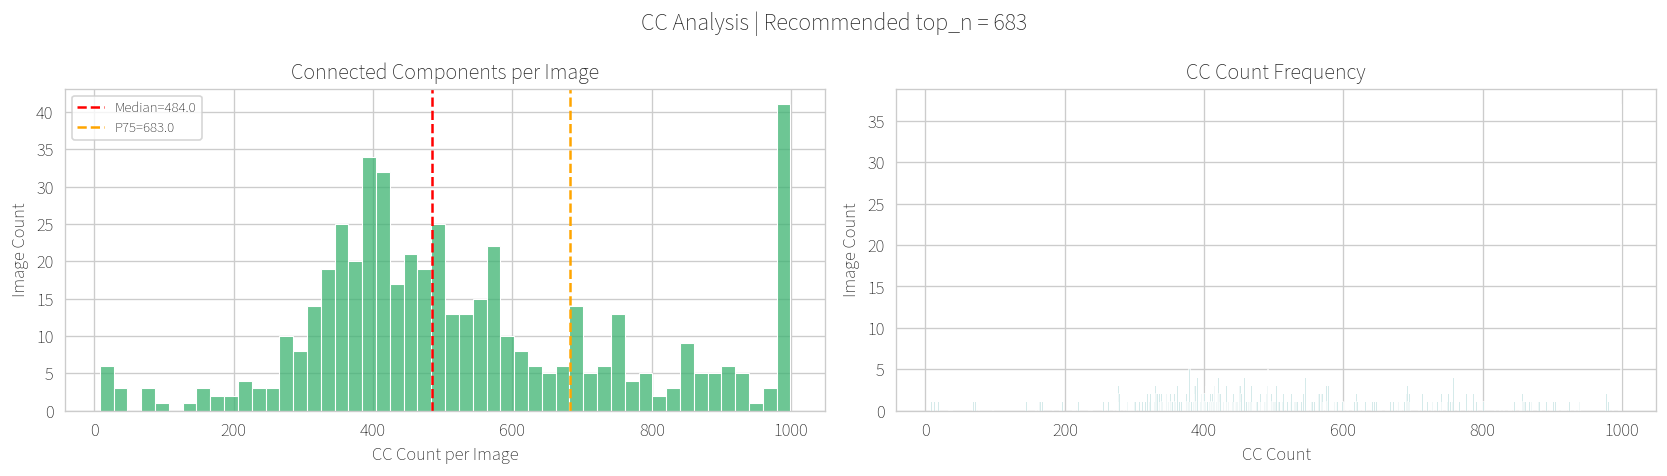

Mean CC: 535.7 | Median: 484.0 | P75: 683 | Max: 999


In [5]:
cc_sample = all_images if len(all_images) <= CC_SAMPLE_N else rng.sample(all_images, CC_SAMPLE_N)
cc_counts = []
for index, p in enumerate(cc_sample):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    binary = binarize(img)
    comps = discover_components(binary, top_n=999, max_bbox_ratio=MAX_BBOX_RATIO,
        padding=0, remove_logo_cfg=True, logo_template_path=LOGO_TEMPLATE,
        logo_mask_region=LOGO_MASK_REGION, use_topology_pruning=USE_TOPOLOGY_PRUNING,
        min_simple_area=MIN_SIMPLE_AREA)
    cc_counts.append(len(comps))

    print(f"{index}/{len(cc_sample)}")

arr = np.array(cc_counts)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
sns.histplot(cc_counts, bins=min(max(cc_counts)+1, 50), ax=ax, color='mediumseagreen', kde=False)
ax.axvline(float(np.median(arr)), color='red', ls='--', label=f'Median={np.median(arr):.1f}')
ax.axvline(float(np.percentile(arr, 75)), color='orange', ls='--', label=f'P75={np.percentile(arr, 75):.1f}')
ax.set_xlabel('CC Count per Image'); ax.set_ylabel('Image Count')
ax.set_title('Connected Components per Image'); ax.legend(fontsize=8)
ax = axes[1]
unique, cnts = np.unique(cc_counts, return_counts=True)
ax.bar(unique, cnts, color='teal', alpha=0.8)
ax.set_xlabel('CC Count'); ax.set_ylabel('Image Count'); ax.set_title('CC Count Frequency')
p75 = int(np.percentile(arr, 75))
fig.suptitle(f'CC Analysis | Recommended top_n = {p75}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Mean CC: {arr.mean():.1f} | Median: {np.median(arr):.1f} | P75: {p75} | Max: {arr.max()}')

## 5. 類別平衡分析

In [6]:
class_counts = {}
for p in all_images:
    try:
        rel = p.relative_to(DATA_DIR)
        cls = rel.parts[0] if len(rel.parts) > 1 else '_flat'
    except ValueError:
        cls = '_flat'
    class_counts[cls] = class_counts.get(cls, 0) + 1

total = sum(class_counts.values())
sorted_cls = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

if len(sorted_cls) > 1:
    names = [c[0] for c in sorted_cls]; counts = [c[1] for c in sorted_cls]
    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(names)*0.5+4), 5))
    ax = axes[0]
    bars = ax.barh(names[::-1], [c for c in counts[::-1]],
                   color=sns.color_palette('tab20', len(names)))
    ax.set_xlabel('Image Count'); ax.set_title('Class Distribution (count)')
    ax = axes[1]
    if len(names) <= 10:
        ax.pie(counts, labels=names, autopct='%1.1f%%', startangle=90)
    else:
        pcts = [c/total*100 for c in counts]
        ax.bar(range(len(counts)), pcts, color=sns.color_palette('tab20', len(names)))
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Percentage (%)')
    ax.set_title('Class Distribution (%)')
    fig.suptitle(f'Class Balance | {len(names)} classes, {total:,} images', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print(f'單一類別 (flat 目錄): {total:,} 張影像')

bal_df = pd.DataFrame(sorted_cls, columns=['class', 'count'])
bal_df['pct'] = (bal_df['count'] / total * 100).round(2)
display(bal_df)

單一類別 (flat 目錄): 94,524 張影像


,class,count,pct
0,_flat,94524,100.0


---
# 🔬 拓撲複雜度分析 (Topological Complexity)

> 以下為額外的拓撲分析，計算 Betti 數、Euler 特徵數、輪廓階層深度等拓撲不變量。

## 6. 單張影像拓撲特徵視覺化

0/4751
1/4751
2/4751
3/4751
4/4751
5/4751
6/4751
7/4751
8/4751
9/4751
10/4751
11/4751
12/4751
13/4751
14/4751
15/4751
16/4751
17/4751
18/4751
19/4751
20/4751
21/4751
22/4751
23/4751
24/4751
25/4751
26/4751
27/4751
28/4751
29/4751
30/4751
31/4751
32/4751
33/4751
34/4751
35/4751
36/4751
37/4751
38/4751
39/4751
40/4751
41/4751
42/4751
43/4751
44/4751
45/4751
46/4751
47/4751
48/4751
49/4751
50/4751
51/4751
52/4751
53/4751
54/4751
55/4751
56/4751
57/4751
58/4751
59/4751
60/4751
61/4751
62/4751
63/4751
64/4751
65/4751
66/4751
67/4751
68/4751
69/4751
70/4751
71/4751
72/4751
73/4751
74/4751
75/4751
76/4751
77/4751
78/4751
79/4751
80/4751
81/4751
82/4751
83/4751
84/4751
85/4751
86/4751
87/4751
88/4751
89/4751
90/4751
91/4751
92/4751
93/4751
94/4751
95/4751
96/4751
97/4751
98/4751
99/4751
100/4751
101/4751
102/4751
103/4751
104/4751
105/4751
106/4751
107/4751
108/4751
109/4751
110/4751
111/4751
112/4751
113/4751
114/4751
115/4751
116/4751
117/4751
118/4751
119/4751
120/4751
121/4751
122/4751
123

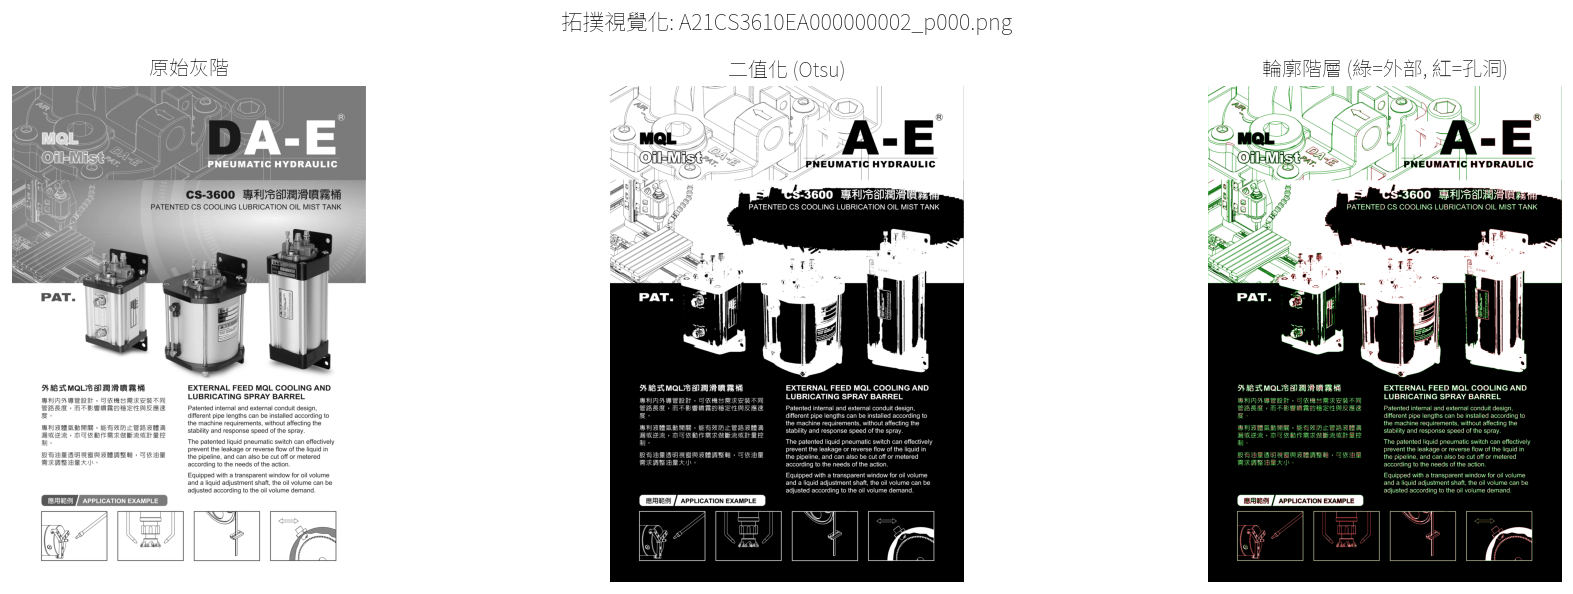

🕳️  孔洞數 (β₁): 2191
📐 輪廓總數: 4751


In [7]:
# 隨機取一張影像做詳細視覺化
demo_img_path = rng.choice(all_images)
demo_gray = cv2.imread(str(demo_img_path), cv2.IMREAD_GRAYSCALE)
demo_binary = binarize(demo_gray)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(demo_gray, cmap='gray'); axes[0].set_title('原始灰階'); axes[0].axis('off')
axes[1].imshow(demo_binary, cmap='gray'); axes[1].set_title('二值化 (Otsu)'); axes[1].axis('off')

# 輪廓視覺化 (RETR_CCOMP)
contours, hierarchy = cv2.findContours(demo_binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
vis = cv2.cvtColor(demo_binary, cv2.COLOR_GRAY2RGB)
colors = [(0,255,0), (255,0,0), (0,0,255), (255,165,0), (148,0,211)]
if hierarchy is not None:
    for i, cnt in enumerate(contours):
        parent = hierarchy[0, i, 3]
        color = (255,0,0) if parent != -1 else (0,255,0)  # 紅=孔洞輪廓, 綠=外部輪廓
        cv2.drawContours(vis, [cnt], -1, color, 1)
        print(f"{i}/{len(contours)}")
axes[2].imshow(vis); axes[2].set_title('輪廓階層 (綠=外部, 紅=孔洞)'); axes[2].axis('off')
fig.suptitle(f'拓撲視覺化: {demo_img_path.name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

n_holes = count_holes(demo_binary)
print(f'🕳️  孔洞數 (β₁): {n_holes}')
print(f'📐 輪廓總數: {len(contours)}')

## 7. 批量拓撲特徵統計 (Betti Numbers & Euler Characteristic)

In [8]:
topo_sample = all_images if len(all_images) <= TOPO_SAMPLE_N else rng.sample(all_images, TOPO_SAMPLE_N)
topo_records = []

for p in topo_sample:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    binary = binarize(img)
    
    # β₀ (connected components) - 使用 4-connectivity for foreground
    n_labels_fg, _ = cv2.connectedComponents(binary, connectivity=4)
    beta_0 = n_labels_fg - 1  # 扣除背景
    
    # β₁ (holes)
    beta_1 = count_holes(binary)
    
    # Euler characteristic: χ = β₀ - β₁
    euler = beta_0 - beta_1
    
    # 輪廓階層深度
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    max_depth = 0
    if hierarchy is not None:
        # 計算最大巢狀深度
        for i in range(len(contours)):
            depth = 0; idx = i
            while hierarchy[0, idx, 3] != -1:
                depth += 1; idx = hierarchy[0, idx, 3]
            max_depth = max(max_depth, depth)
    
    # 輪廓面積分佈
    areas = [cv2.contourArea(c) for c in contours if cv2.contourArea(c) > 0]
    
    topo_records.append({
        'file': p.name,
        'β₀ (components)': beta_0,
        'β₁ (holes)': beta_1,
        'χ (Euler)': euler,
        'n_contours': len(contours),
        'max_hierarchy_depth': max_depth,
        'mean_contour_area': np.mean(areas) if areas else 0,
        'std_contour_area': np.std(areas) if areas else 0,
        'complexity_score': beta_0 + 2 * beta_1 + max_depth,  # 自訂複雜度
    })

topo_df = pd.DataFrame(topo_records)
display(topo_df.describe().round(2))

,β₀ (components),β₁ (holes),χ (Euler),n_contours,max_hierarchy_depth,mean_contour_area,std_contour_area,complexity_score
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,3066.65,2049.62,1017.03,3170.17,6.75,35083.94,765701.24,7172.64
std,8493.94,6068.97,5801.07,6408.16,1.25,21052.94,353659.40,19238.69
min,25.00,76.00,-6665.00,143.00,2.00,894.36,11530.86,436.00
25%,590.75,448.75,-22.50,1059.75,6.00,24555.06,543046.50,1548.00
50%,861.00,688.00,139.00,1580.00,7.00,33238.99,765102.83,2330.00
75%,1291.50,1176.75,241.00,2421.25,7.00,42838.49,959615.28,3800.75
max,71156.00,44256.00,69952.00,52177.00,14.00,239803.49,3444364.05,152182.00


## 8. 拓撲特徵分佈圖

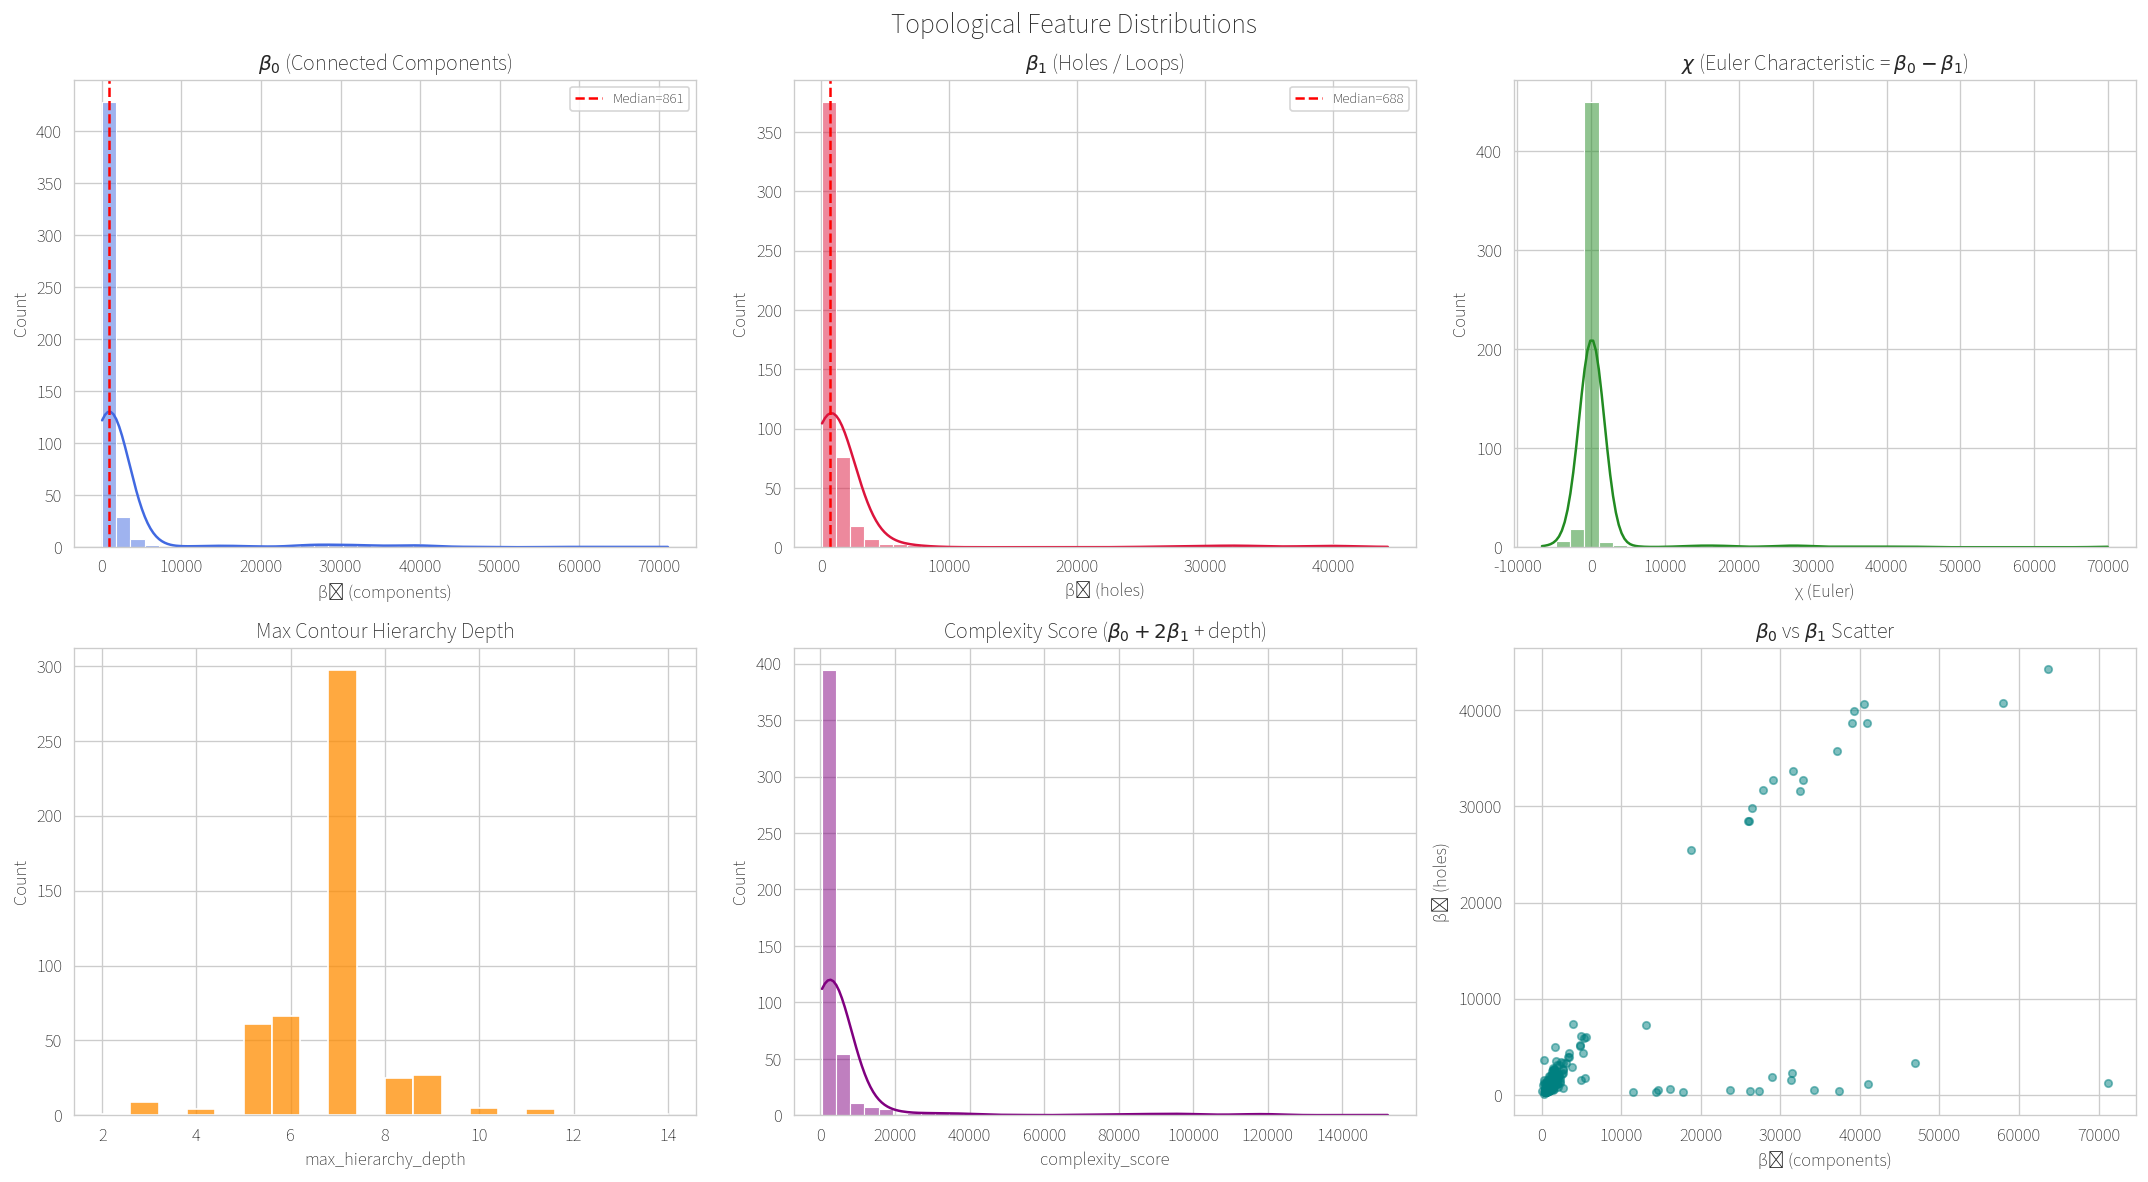

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# β₀ 分佈
sns.histplot(topo_df['β₀ (components)'], bins=40, ax=axes[0,0], color='royalblue', kde=True)
axes[0,0].set_title(r'$\beta_0$ (Connected Components)')
axes[0,0].axvline(topo_df['β₀ (components)'].median(), color='red', ls='--', label=f"Median={topo_df['β₀ (components)'].median():.0f}")
axes[0,0].legend(fontsize=8)

# β₁ 分佈
sns.histplot(topo_df['β₁ (holes)'], bins=40, ax=axes[0,1], color='crimson', kde=True)
axes[0,1].set_title(r'$\beta_1$ (Holes / Loops)')
axes[0,1].axvline(topo_df['β₁ (holes)'].median(), color='red', ls='--', label=f"Median={topo_df['β₁ (holes)'].median():.0f}")
axes[0,1].legend(fontsize=8)

# Euler 特徵數分佈
sns.histplot(topo_df['χ (Euler)'], bins=40, ax=axes[0,2], color='forestgreen', kde=True)
axes[0,2].set_title(r'$\chi$ (Euler Characteristic = $\beta_0 - \beta_1$)')

# 階層深度分佈
sns.histplot(topo_df['max_hierarchy_depth'], bins=20, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('Max Contour Hierarchy Depth')

# 複雜度分數分佈
sns.histplot(topo_df['complexity_score'], bins=40, ax=axes[1,1], color='purple', kde=True)
axes[1,1].set_title(r'Complexity Score ($\beta_0 + 2\beta_1$ + depth)')

# β₀ vs β₁ 散佈圖
axes[1,2].scatter(topo_df['β₀ (components)'], topo_df['β₁ (holes)'], alpha=0.5, s=20, c='teal')
axes[1,2].set_xlabel('β₀ (components)'); axes[1,2].set_ylabel('β₁ (holes)')
axes[1,2].set_title(r'$\beta_0$ vs $\beta_1$ Scatter')

fig.suptitle('Topological Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. 元件級拓撲分析

0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
0/5
1/5
2/5
3/5
4/5
📊 分析了 30 張影像的 145 個元件


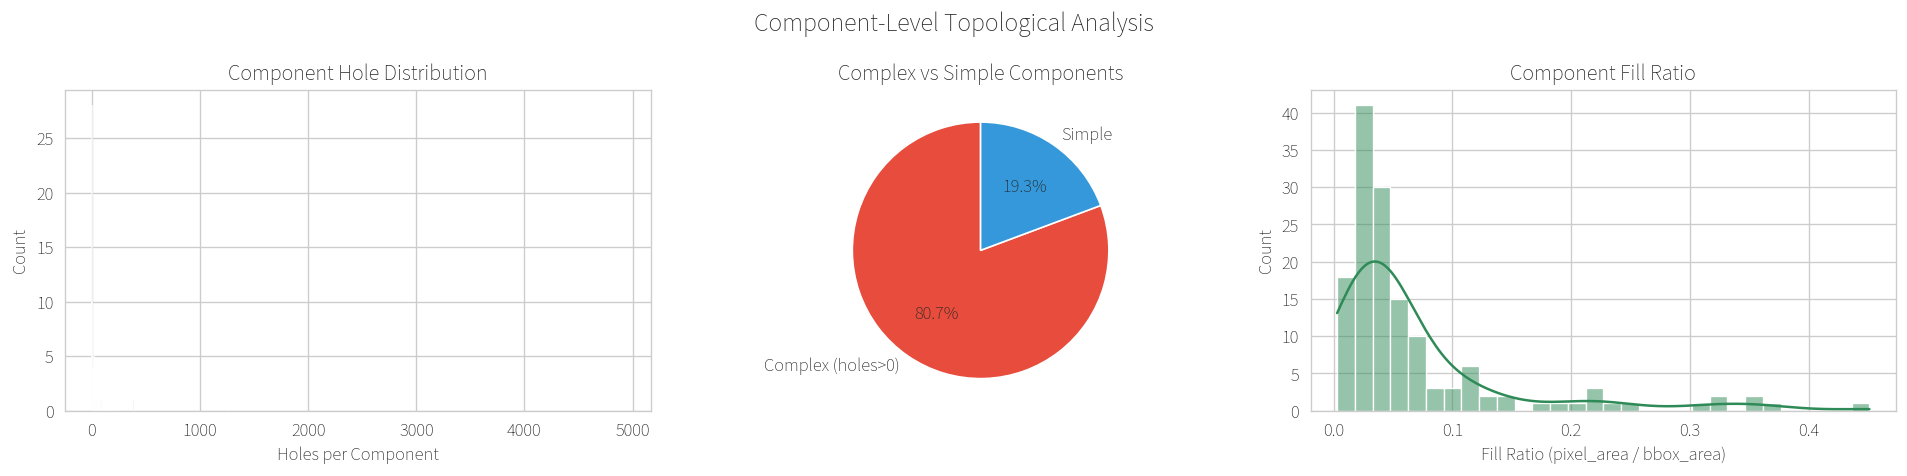

area                                                        \
            count        mean         std     min        25%        50%   
is_complex                                                                
False        28.0   439285.50  1094859.58  5472.0   74852.25   181869.0   
True        117.0  2160162.24  2518553.82  4216.0  543016.00  1605630.0   

                                   pixel_area             ... n_contours  \
                   75%         max      count       mean  ...        75%   
is_complex                                                ...              
False        275820.25   5808660.0       28.0    5154.93  ...        1.0   
True        2737729.00  16701672.0      117.0  115363.06  ...       81.0   

                   fill_ratio                                            
               max      count  mean   std   min   25%   50%   75%   max  
is_complex                                                               
False          1.0       28.0  0.06  0.08  0.00  0.02  0.02  0.04  0.33  
True        4922.0      117.0  0.07  0.08  0.01  0.03  0.04  0.07  0.45  

[2 rows x 40 columns]

In [10]:
# 分析單張影像中各元件的拓撲特徵
comp_topo_records = []
comp_sample = all_images if len(all_images) <= 30 else rng.sample(all_images, 30)

for p in comp_sample:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    binary = binarize(img)
    comps = discover_components(binary, top_n=TOP_N, max_bbox_ratio=MAX_BBOX_RATIO,
        padding=PADDING, remove_logo_cfg=True, logo_template_path=LOGO_TEMPLATE,
        logo_mask_region=LOGO_MASK_REGION, use_topology_pruning=USE_TOPOLOGY_PRUNING,
        min_simple_area=MIN_SIMPLE_AREA)
    for i, c in enumerate(comps):
        crop = c['crop']
        topo = analyze_topology(crop)
        # 輪廓分析
        cnts, hier = cv2.findContours(crop, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        comp_topo_records.append({
            'file': p.name, 'comp_idx': i,
            'area': c['area'], 'pixel_area': c['pixel_area'],
            'n_holes': topo['n_holes'], 'is_complex': topo['is_complex'],
            'n_contours': len(cnts),
            'fill_ratio': c['pixel_area'] / max(c['area'], 1),
        })

        print(f"{i}/{len(comps)}")

comp_df = pd.DataFrame(comp_topo_records)
print(f'📊 分析了 {len(comp_sample)} 張影像的 {len(comp_df)} 個元件')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# 元件孔洞數分佈
hole_counts = comp_df['n_holes'].value_counts().sort_index()
axes[0].bar(hole_counts.index, hole_counts.values, color='crimson', alpha=0.8)
axes[0].set_xlabel('Holes per Component'); axes[0].set_ylabel('Count')
axes[0].set_title('Component Hole Distribution')

# 複雜 vs 簡單元件
complex_pct = comp_df['is_complex'].mean() * 100
axes[1].pie([complex_pct, 100-complex_pct], labels=['Complex (holes>0)', 'Simple'],
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db'], startangle=90)
axes[1].set_title('Complex vs Simple Components')

# Fill ratio 分佈
sns.histplot(comp_df['fill_ratio'], bins=30, ax=axes[2], color='seagreen', kde=True)
axes[2].set_xlabel('Fill Ratio (pixel_area / bbox_area)')
axes[2].set_title('Component Fill Ratio')

fig.suptitle('Component-Level Topological Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
display(comp_df.groupby('is_complex')[['area','pixel_area','n_holes','n_contours','fill_ratio']].describe().round(2))

## 10. 拓撲剪枝效果分析

拓撲保持率: 100.0%


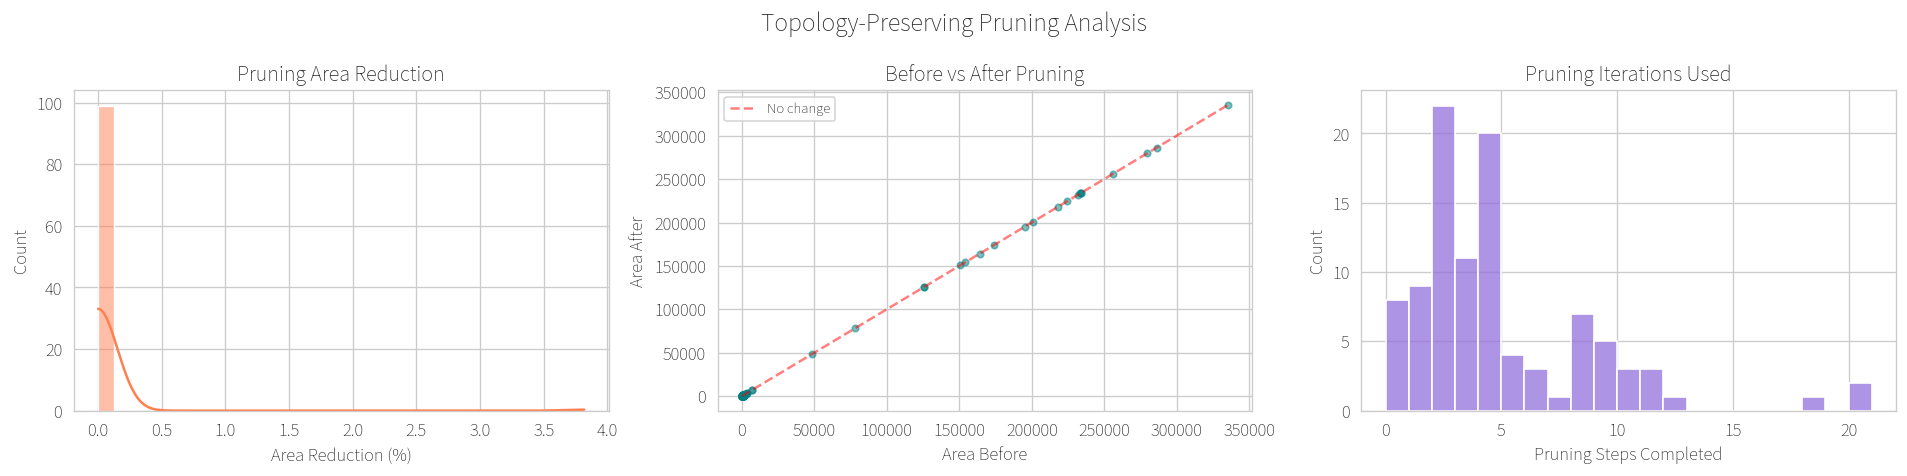

In [11]:
# 分析剪枝前後的拓撲不變性
pruning_records = []
prune_sample = all_images if len(all_images) <= 20 else rng.sample(all_images, 20)

for p in prune_sample:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    binary = binarize(img)
    h, w = binary.shape
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    for i in range(1, min(num_labels, 6)):
        x = int(stats[i, cv2.CC_STAT_LEFT]); y = int(stats[i, cv2.CC_STAT_TOP])
        cw = int(stats[i, cv2.CC_STAT_WIDTH]); ch = int(stats[i, cv2.CC_STAT_HEIGHT])
        comp_crop = (labels[y:y+ch, x:x+cw] == i).astype(np.uint8) * 255
        
        holes_before = count_holes(comp_crop)
        area_before = int(comp_crop.sum() / 255)
        
        pruned, history = topology_preserving_pruning(comp_crop, max_iters=PRUNING_ITERS, start_ksize=PRUNING_KSIZE)
        holes_after = count_holes(pruned)
        area_after = int(pruned.sum() / 255)
        
        pruning_records.append({
            'file': p.name, 'comp': i,
            'holes_before': holes_before, 'holes_after': holes_after,
            'area_before': area_before, 'area_after': area_after,
            'area_reduction': (1 - area_after/max(area_before,1)) * 100,
            'topology_preserved': holes_before == holes_after,
            'pruning_steps': len(history),
        })

prune_df = pd.DataFrame(pruning_records)
print(f'拓撲保持率: {prune_df["topology_preserved"].mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(prune_df['area_reduction'], bins=30, ax=axes[0], color='coral', kde=True)
axes[0].set_xlabel('Area Reduction (%)'); axes[0].set_title('Pruning Area Reduction')

axes[1].scatter(prune_df['area_before'], prune_df['area_after'], alpha=0.5, s=15, c='teal')
max_a = max(prune_df['area_before'].max(), prune_df['area_after'].max())
axes[1].plot([0, max_a], [0, max_a], 'r--', alpha=0.5, label='No change')
axes[1].set_xlabel('Area Before'); axes[1].set_ylabel('Area After')
axes[1].set_title('Before vs After Pruning'); axes[1].legend(fontsize=8)

sns.histplot(prune_df['pruning_steps'], bins=range(0, PRUNING_ITERS+2), ax=axes[2], color='mediumpurple')
axes[2].set_xlabel('Pruning Steps Completed'); axes[2].set_title('Pruning Iterations Used')

fig.suptitle('Topology-Preserving Pruning Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. 前處理管線預覽 (Preview)

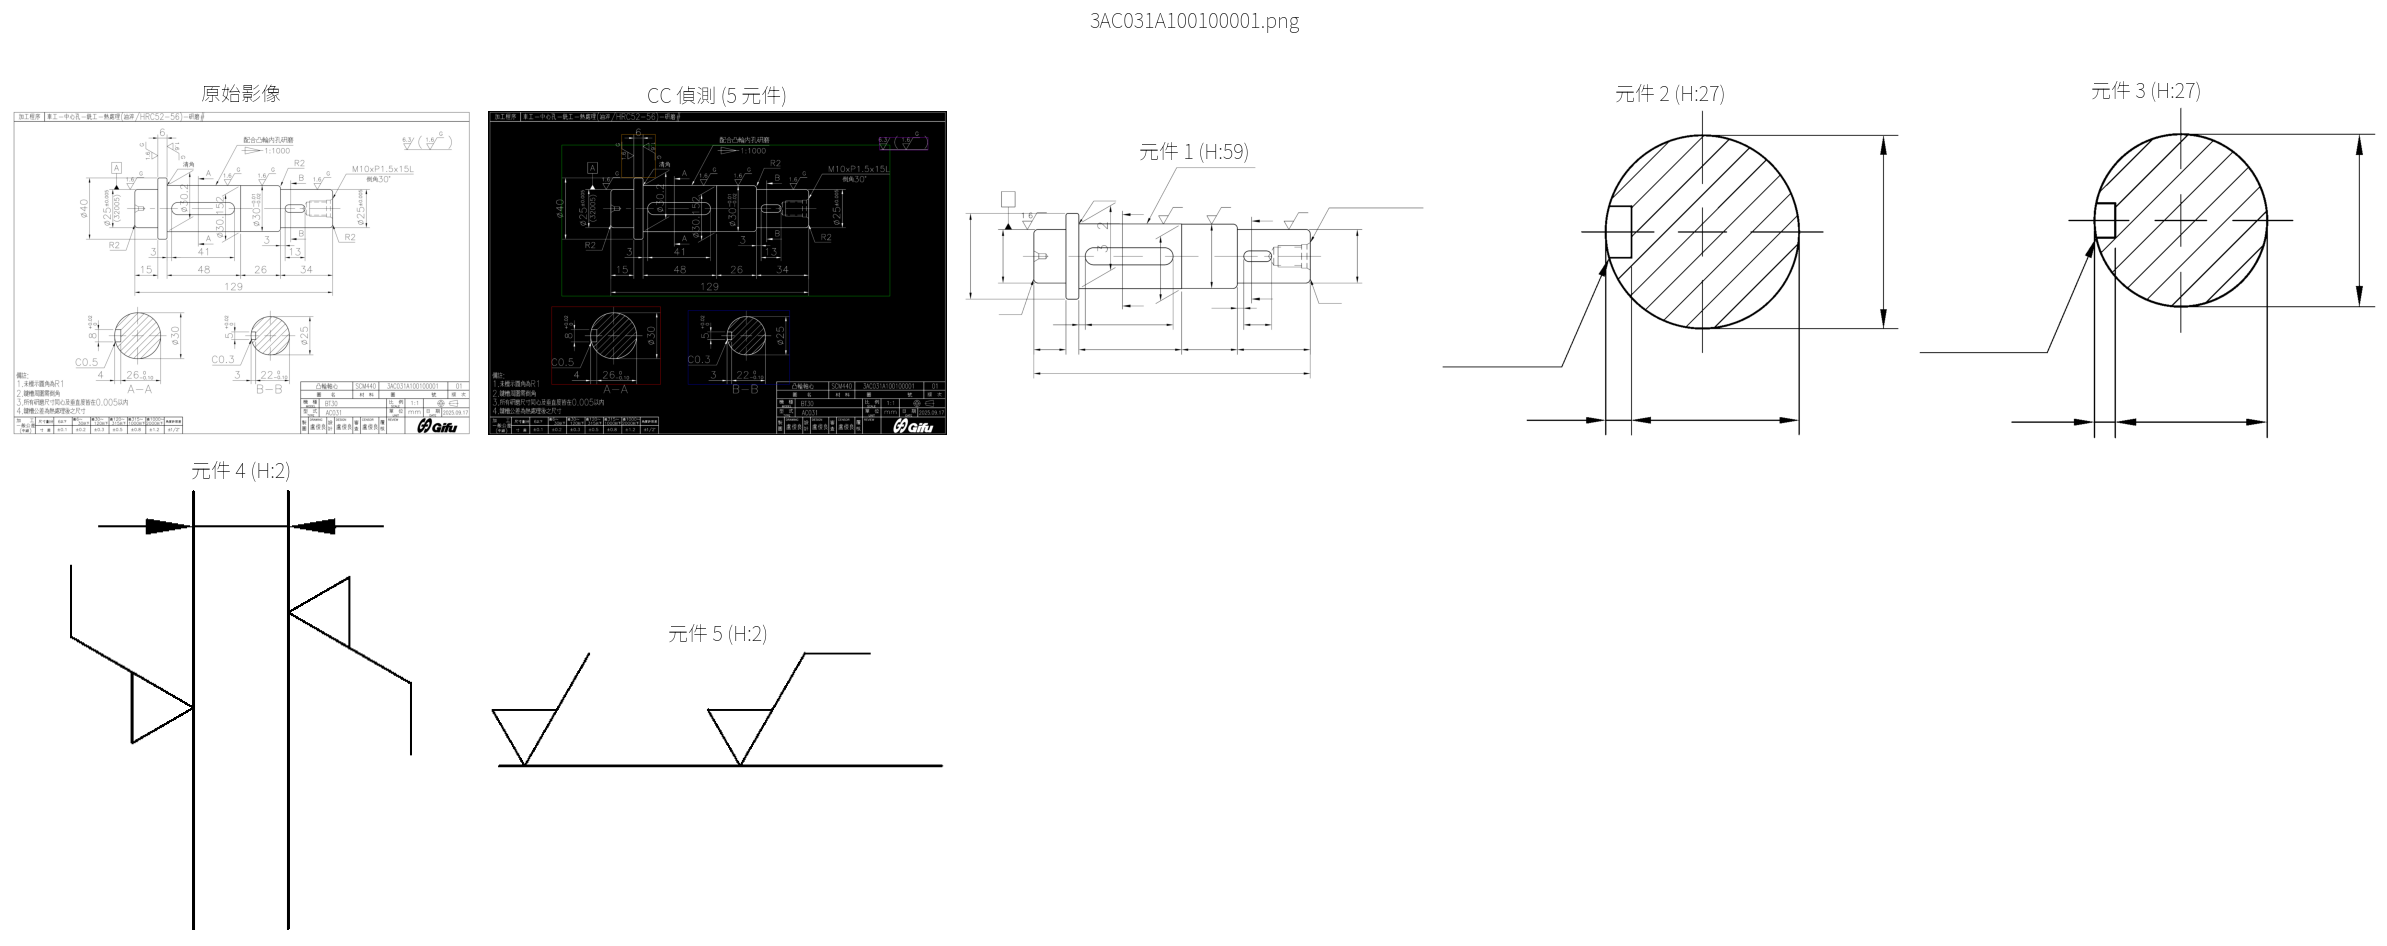

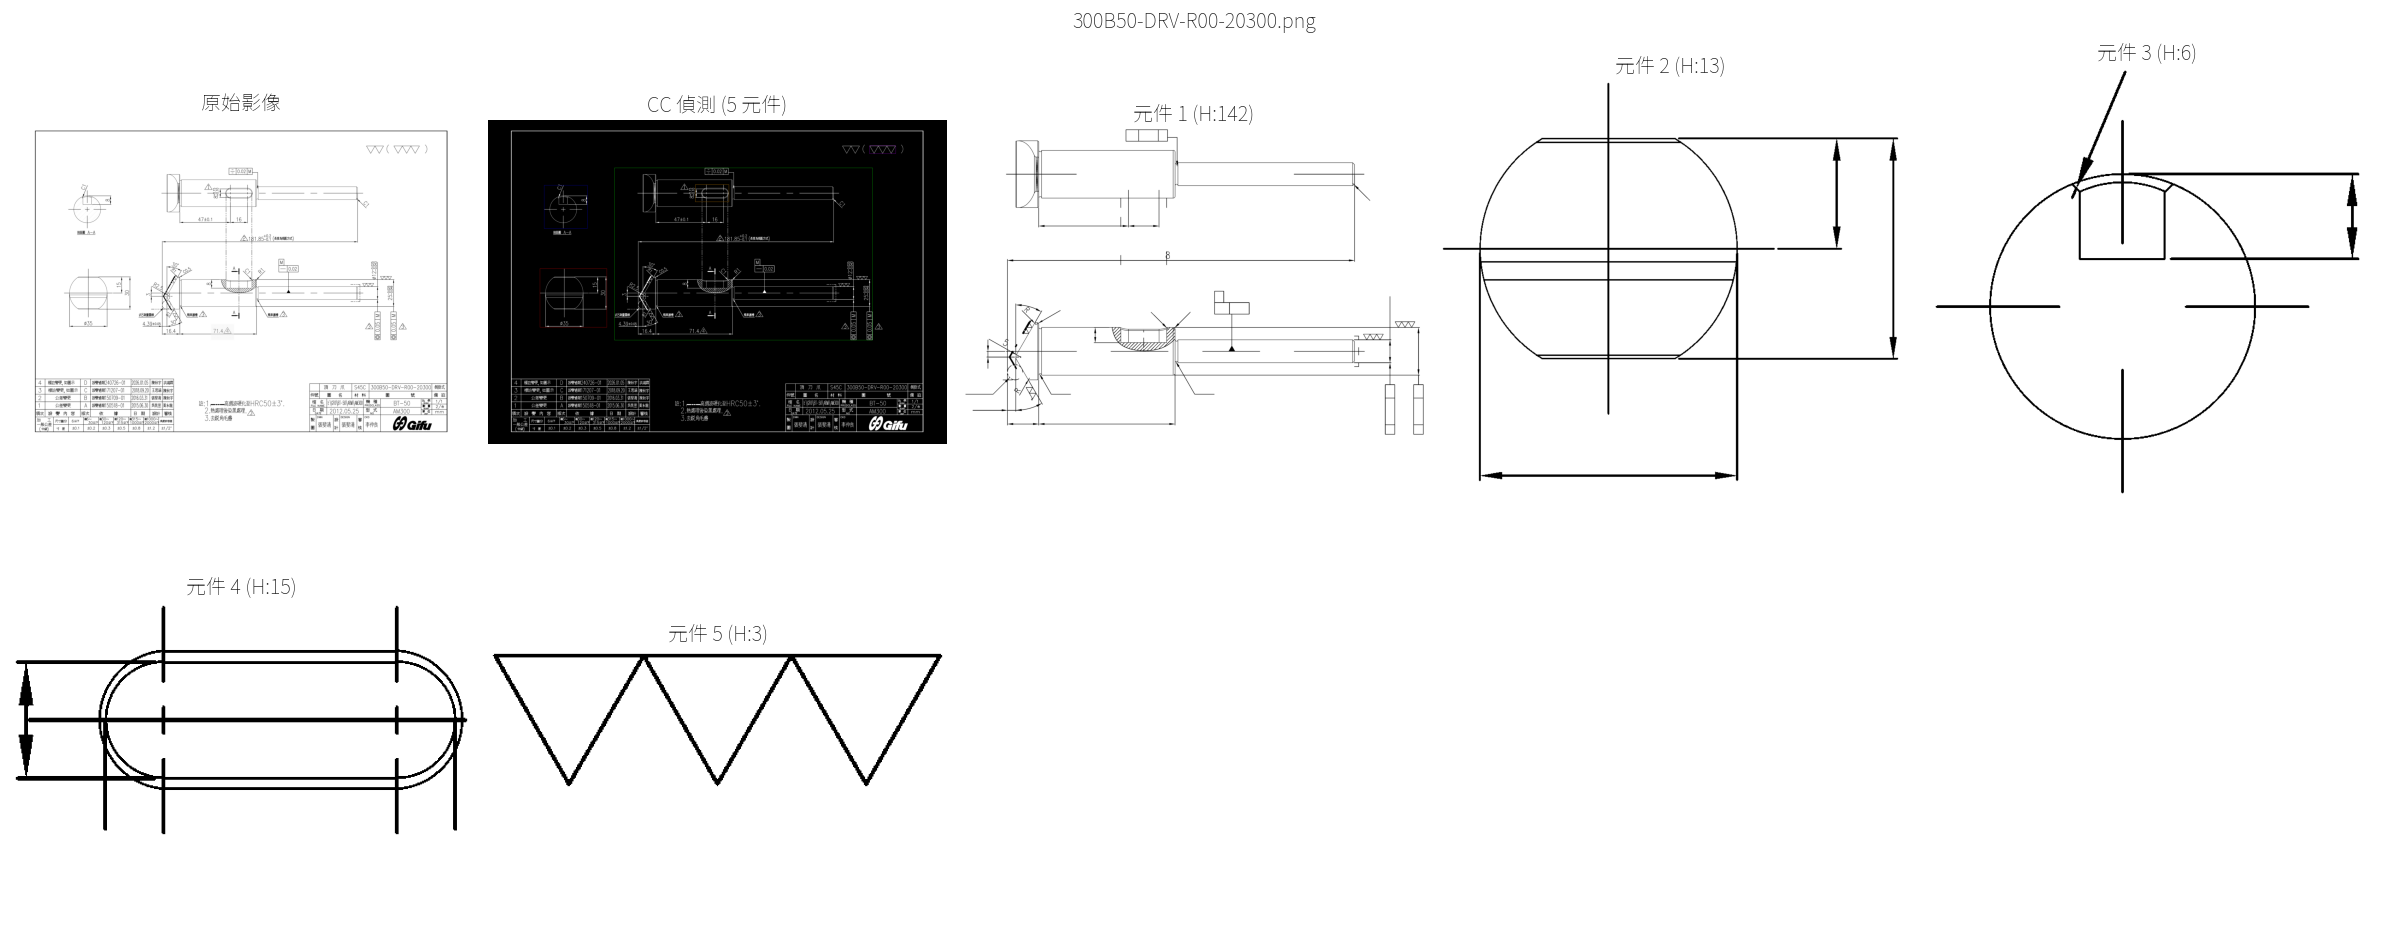

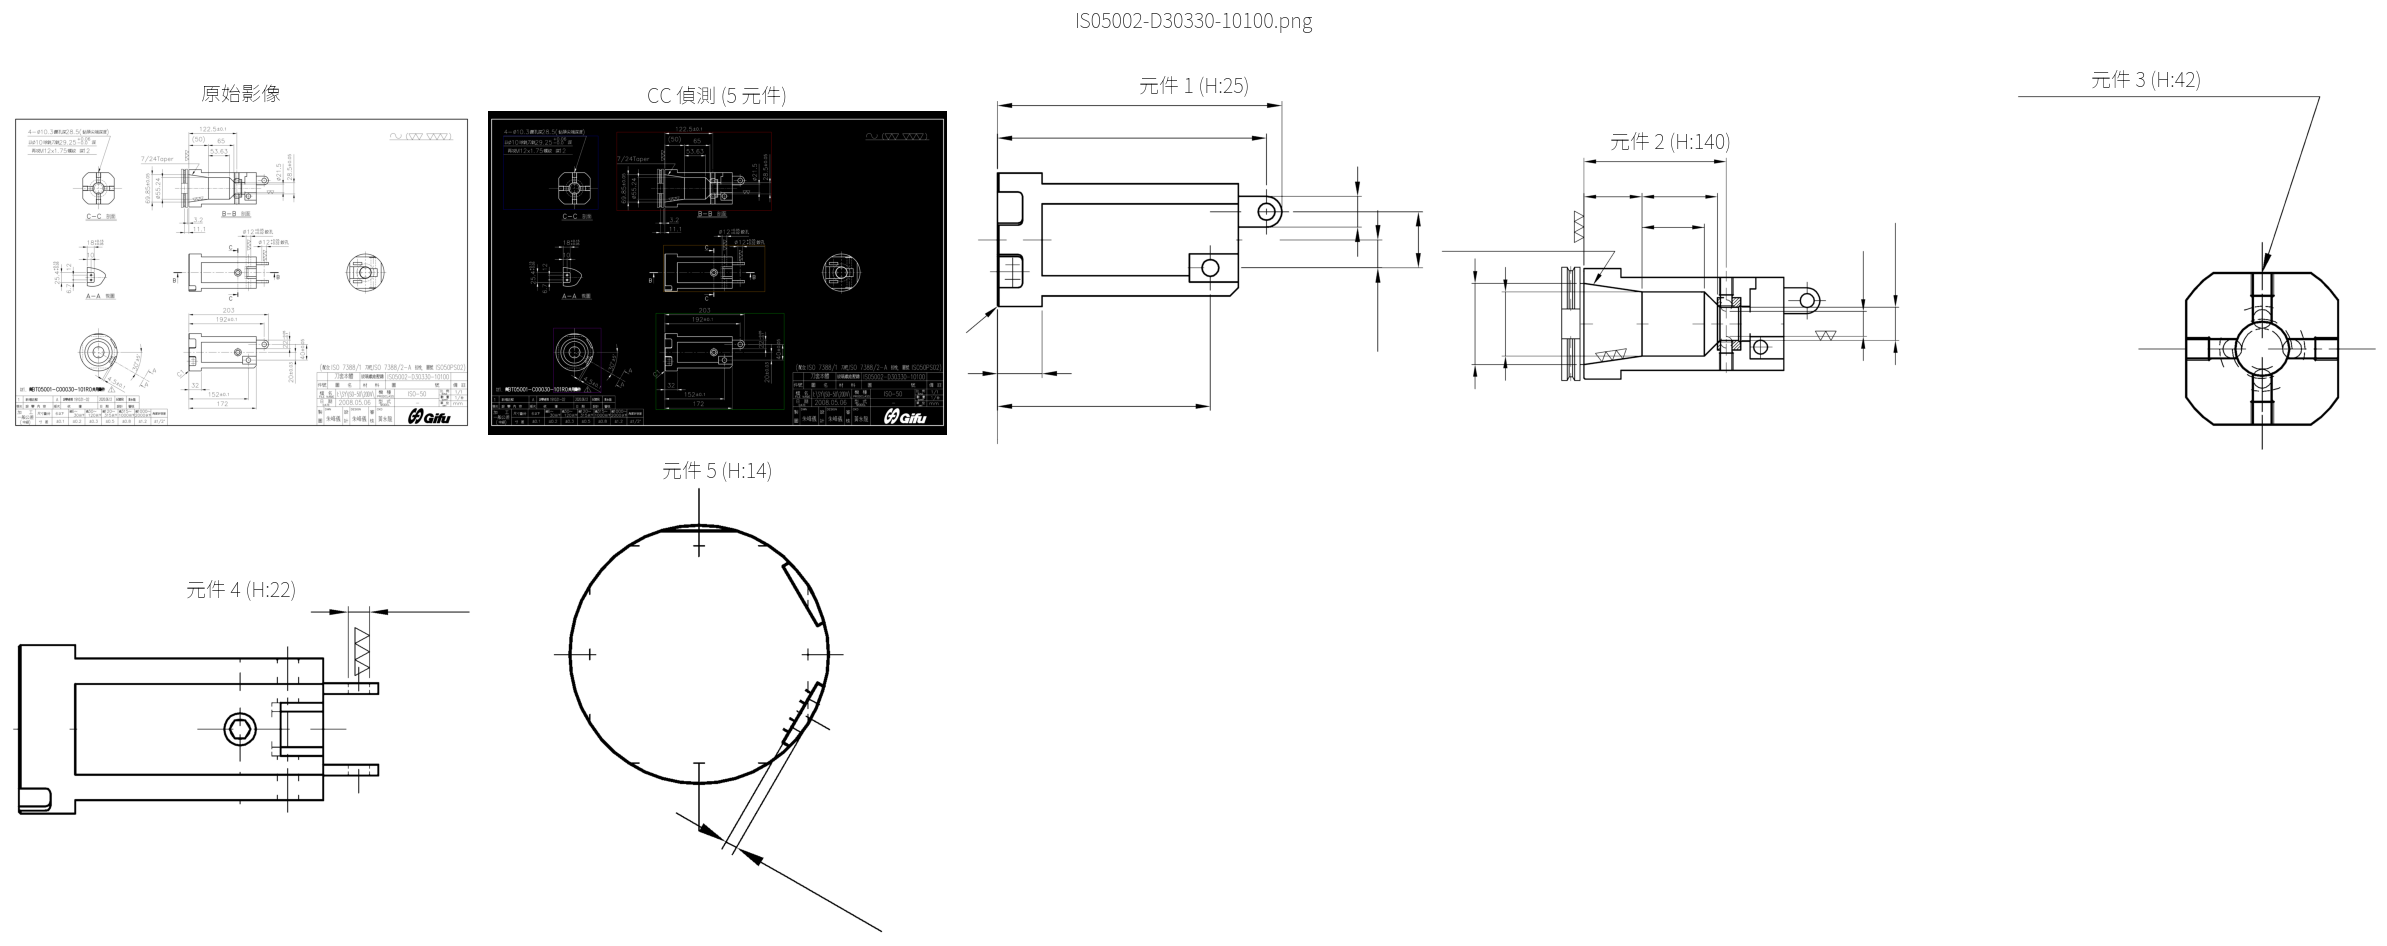

In [12]:
# 隨機抽 3 張做完整管線預覽
preview_n = min(3, len(all_images))
preview_imgs = rng.sample(all_images, preview_n)

for img_path in preview_imgs:
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None: continue
    
    binary = binarize(gray)
    comps = discover_components(binary, top_n=TOP_N, max_bbox_ratio=MAX_BBOX_RATIO,
        padding=PADDING, remove_logo_cfg=True, logo_template_path=LOGO_TEMPLATE,
        logo_mask_region=LOGO_MASK_REGION, use_topology_pruning=USE_TOPOLOGY_PRUNING,
        min_simple_area=MIN_SIMPLE_AREA)
    
    n_stages = 2 + len(comps)  # original + binary + components
    cols = min(n_stages, 5)
    rows = (n_stages + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes_flat = np.array(axes).flatten() if n_stages > 1 else [axes]
    
    axes_flat[0].imshow(gray, cmap='gray'); axes_flat[0].set_title('原始影像'); axes_flat[0].axis('off')
    
    vis = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
    cc_colors = [(0,220,0),(220,0,0),(0,0,220),(220,140,0),(160,0,220)]
    for rank, c in enumerate(comps):
        x1,y1,x2,y2 = c['bbox']
        color = cc_colors[rank % len(cc_colors)]
        cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
    axes_flat[1].imshow(vis); axes_flat[1].set_title(f'CC 偵測 ({len(comps)} 元件)'); axes_flat[1].axis('off')
    
    for i, c in enumerate(comps):
        inv = 255 - c['crop']
        padded = cv2.copyMakeBorder(inv, PADDING, PADDING, PADDING, PADDING, cv2.BORDER_CONSTANT, value=255)
        if i+2 < len(axes_flat):
            axes_flat[i+2].imshow(padded, cmap='gray'); axes_flat[i+2].set_title(f'元件 {i+1} (H:{c["n_holes"]})'); axes_flat[i+2].axis('off')
    
    for ax in axes_flat[n_stages:]: ax.axis('off')
    fig.suptitle(f'{img_path.name}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

## 12. 拓撲複雜度摘要

In [13]:
print('=' * 60)
print('📊 拓撲複雜度分析摘要')
print('=' * 60)
print(f'\n分析影像數: {len(topo_df)}')
print(f'\n--- Betti Numbers ---')
print(f'β₀ (components): mean={topo_df["β₀ (components)"].mean():.1f}, median={topo_df["β₀ (components)"].median():.0f}, max={topo_df["β₀ (components)"].max()}')
print(f'β₁ (holes):      mean={topo_df["β₁ (holes)"].mean():.1f}, median={topo_df["β₁ (holes)"].median():.0f}, max={topo_df["β₁ (holes)"].max()}')
print(f'\n--- Euler Characteristic ---')
print(f'χ = β₀ - β₁:     mean={topo_df["χ (Euler)"].mean():.1f}, median={topo_df["χ (Euler)"].median():.0f}')
print(f'\n--- Hierarchy & Complexity ---')
print(f'Max depth:        mean={topo_df["max_hierarchy_depth"].mean():.1f}, max={topo_df["max_hierarchy_depth"].max()}')
print(f'Complexity score: mean={topo_df["complexity_score"].mean():.1f}, median={topo_df["complexity_score"].median():.0f}')
print(f'\n--- Component Level ({len(comp_df)} components) ---')
print(f'Complex ratio:    {comp_df["is_complex"].mean():.1%}')
print(f'Mean holes/comp:  {comp_df["n_holes"].mean():.2f}')
print(f'\n--- Pruning ({len(prune_df)} components) ---')
print(f'Topology preserved: {prune_df["topology_preserved"].mean():.1%}')
print(f'Mean area reduction: {prune_df["area_reduction"].mean():.1f}%')
print('\n' + '=' * 60)
print('✅ 分析完成！')

📊 拓撲複雜度分析摘要

分析影像數: 500

--- Betti Numbers ---
β₀ (components): mean=3066.7, median=861, max=71156
β₁ (holes):      mean=2049.6, median=688, max=44256

--- Euler Characteristic ---
χ = β₀ - β₁:     mean=1017.0, median=139

--- Hierarchy & Complexity ---
Max depth:        mean=6.8, max=14
Complexity score: mean=7172.6, median=2330

--- Component Level (145 components) ---
Complex ratio:    80.7%
Mean holes/comp:  89.92

--- Pruning (100 components) ---
Topology preserved: 100.0%
Mean area reduction: 0.0%

✅ 分析完成！
